In [3]:
import torch 
from torch import nn 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 
import torch.nn as nn 
import torchvision.datasets as datasets 
from torchvision import transforms
from torch.utils.data import DataLoader

In [4]:
Batch_size = 32
PIL_transform = transforms.Compose([transforms.RandomRotation(10),
                                    transforms.ToTensor()])
train_data = datasets.MNIST('./data', train= True, transform=PIL_transform, download=True)
test_data = datasets.MNIST('./data',train= False, transform= PIL_transform, download= True)

train_dataloader = DataLoader(train_data,batch_size=Batch_size, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size= Batch_size)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9912422/9912422 [06:48<00:00, 24292.81it/s]  


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28881/28881 [00:00<00:00, 86516.91it/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1648877/1648877 [00:02<00:00, 583904.78it/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4542/4542 [00:00<00:00, 3066730.32it/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



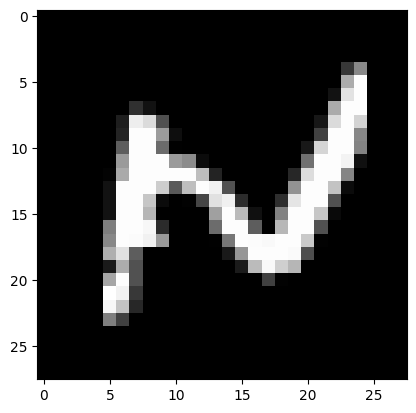

In [11]:
#visualize the data sample 
image_sample = next(iter(train_data))
plt.imshow(image_sample[0].transpose(0,2), cmap ='gray')
plt.show()


In [42]:
embed_dim = 20
num_channel = image_sample[0].shape[0]
num_classes = 10
image_size = 28
attention_head = 4 
patch_size = 7
patch_num = (image_size//patch_size) * (image_size//patch_size)
transformer_block = 4
dropout = 0.1

#Create the patch embedding class
class PatchesEmbedding (nn.Module):
    '''Patch embedding class consist of a convolutional layer with kernel size and stride equal to patch size to create non overlapping 
    patches and then flatten the output and transpose it to get the patch embedding'''
    def __init__(self):
        super().__init__()
        self.patch_embedding = nn.Sequential(
            nn.Conv2d(num_channel,embed_dim,kernel_size=patch_size, stride=patch_size)
        )
    def forward(self,x):
        x = self.patch_embedding(x)
        x = x.flatten(2)
        x= x.transpose(1,2)
        return x 

In [43]:
# transformer encoder  
class TransfomerEncoder(nn.Module):
    def __init__(self):
        '''Transformer encoder block consist of multi head attention and MLP with residual connection and layernorm
        >- Layernorm >- Multihead(With Residual connection) >- MLP (With Residaul connection)'''
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.multi_head = nn.MultiheadAttention(embed_dim, attention_head, batch_first= True)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.MLP = nn.Sequential(
            nn.Linear(embed_dim,embed_dim *4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim*4,embed_dim),
            nn.Dropout(dropout)
        )
    def forward (self,x):
        residual1 = x
        x = self.norm1(x)
        x = self.multi_head(x,x,x)[0] + residual1
        residual2 = x
        x = self.norm2(x)
        x = self.MLP(x) + residual2
        return x
    

In [44]:
#Multilayer Perceptron classifier 
class MLPhead(nn.Module):
    def __init__(self):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim,num_classes)
        )
    def forward(self,x):
        return self.classifier(x)

In [45]:
class VisionTransformer (nn.Module):
    def __init__(self): 
        super().__init__()
        self.PatchEmbedding = PatchesEmbedding()
        self.cls = nn.Parameter(torch.randn(1,1,embed_dim))
        self.positional_embed = nn.Parameter(torch.randn(1,patch_num +1,embed_dim))
        self.MSA = nn.Sequential(
            *[TransfomerEncoder() for _ in range(transformer_block)])
        self.classifier = MLPhead()

    def forward(self,x):
        x = self.PatchEmbedding(x)
        B= x.shape[0]
        cls = self.cls.expand(B,-1,-1)
        x = torch.cat((cls,x), dim=1)
        x = x + self.positional_embed
        x = self.MSA(x)
        x = x[:,0]
        x = self.classifier(x)
        return x



In [46]:
def accuracy (y_pred, ground_truth):
    y_pred = torch.argmax(y_pred, dim=1)
    correct = (y_pred==ground_truth).sum().item()
    acc = correct/ len(ground_truth)
    return acc
device = 'mps' if torch.backends.mps.is_available() else 'cpu'
model = VisionTransformer().to(device)
optimizer = torch.optim.Adam(model.parameters(),
                             lr= 0.01)
loss_fn = nn.CrossEntropyLoss()
#optimizer 
#loss 
#accuracy 

In [47]:
# training 
epochs = 30
epoch_history = []
epoch_loss_history = []
epoch_accuracy_history = []
epoch_val_accuracy_history = []
epoch_val_loss_history = []

for epoch in range(1,epochs+1):
    epoch_loss = 0 
    epoch_accuracy = 0 
    model.train()
    for x,y in train_dataloader:
        x= x.to(device)
        y= y.to(device)
        y_pred = model(x)
        loss = loss_fn(y_pred,y)
        optimizer.zero_grad()
        acc = accuracy(y_pred,y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() 
        epoch_accuracy += acc

    model.eval()
    with torch.inference_mode():
        epoch_val_loss =0
        epoch_val_accuracy = 0
        for x,y in test_dataloader:
            x= x.to(device)
            y= y.to(device)
            y_pred = model(x)
            loss = loss_fn(y_pred,y)
            acc = accuracy(y_pred,y)
            epoch_val_loss += loss.item() 
            epoch_val_accuracy += acc
    epoch_loss/= len(train_dataloader)
    epoch_accuracy/= len(train_dataloader)
    epoch_accuracy_history.append(epoch_accuracy)
    epoch_loss_history.append(epoch_loss)
    epoch_history.append(epoch)    
    epoch_val_loss/= len(test_dataloader)
    epoch_val_accuracy/= len(test_dataloader)
    epoch_val_accuracy_history.append(epoch_val_accuracy)
    epoch_val_loss_history.append(epoch_val_loss)
    if epoch%5 ==0:
        print(f'At epoch {epoch}, the validation accuracy is : {epoch_val_accuracy} and the validation loss is {epoch_val_loss}')
        print(f'At epoch {epoch}, the training accuracy is : {epoch_accuracy} and the loss is {epoch_loss}')



At epoch 5, the validation accuracy is : 0.9455870607028753 and the validation loss is 0.1655150755891017
At epoch 5, the training accuracy is : 0.9314 and the loss is 0.22911749033095935
At epoch 10, the validation accuracy is : 0.9472843450479234 and the validation loss is 0.17070075910640345
At epoch 10, the training accuracy is : 0.93805 and the loss is 0.20773801393844188
At epoch 15, the validation accuracy is : 0.9648562300319489 and the validation loss is 0.11764765413702664
At epoch 15, the training accuracy is : 0.94325 and the loss is 0.19214817599132658
At epoch 20, the validation accuracy is : 0.9616613418530351 and the validation loss is 0.1338597785935517
At epoch 20, the training accuracy is : 0.9443666666666667 and the loss is 0.18520838694019864
At epoch 25, the validation accuracy is : 0.954073482428115 and the validation loss is 0.15356839104974346
At epoch 25, the training accuracy is : 0.94525 and the loss is 0.18428077217663327
At epoch 30, the validation accurac

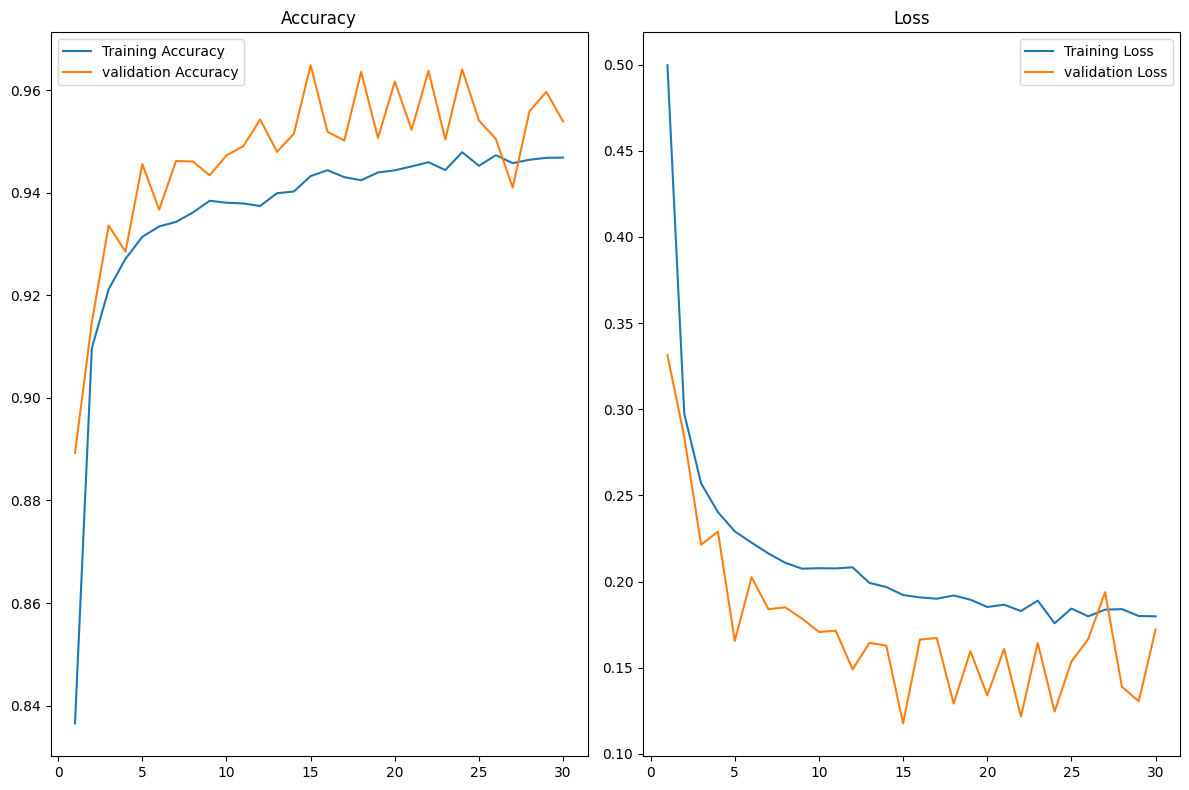

In [49]:
#visualize the training history and validation history 
fig, ax = plt.subplots(1,2,figsize=(12,8))
ax[0].plot(epoch_history, epoch_accuracy_history,label='Training Accuracy')
ax[0].set_title('Accuracy')
ax[0].plot(epoch_history, epoch_val_accuracy_history, label = 'validation Accuracy')
ax[0].legend()
ax[1].plot(epoch_history, epoch_loss_history, label = 'Training Loss')
ax[1].plot(epoch_history, epoch_val_loss_history, label = 'validation Loss')
ax[1].set_title('Loss')
ax[1].legend()
plt.tight_layout()
plt.show()